<a href="https://colab.research.google.com/github/Allansigutta/Data-Analytic-Capstone/blob/main/capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Programming: Intermediate Capstone Project
**Student Name:** [OUMA ALLAN SIGUTTA]  
**Student ID:** [26/05293]  
**Date:** July 14, 2026  

### Project Description
This project performs an end-to-end data analysis on a multi-year retail sales dataset, involving data cleaning, exploratory data visualization, predictive modeling using linear regression to forecast net revenue, and a final business-oriented synthesis.

ENVIRONMENT SET UP

In [4]:
# ==========================================
# STEP 1: ENVIRONMENT SETUP
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#ingores warning during cleaning
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
print("finished setup for environment")

finished setup for environment


STEP 2 : LOADING AND INSPECTING DATASET


In [5]:
# ==========================================
# STEP 2: LOAD AND INSPECT THE DATASET
# ==========================================
# Import panda
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Connect  notebook to  Google Drive folder
drive.mount ('/content/gdrive')

# 2. project folder project variable
DK_CAPSTONE = "/content/gdrive/My Drive/Colab Notebooks/CAPSTONE/"

print(" Capstone Drive mounted and librariEs imported!")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
 Capstone Drive mounted and librariEs imported!


In [6]:
# Load the dataset
df = pd.read_csv(DK_CAPSTONE + "Capstone_Project_data.csv")
df


,date,region,product_category,units_sold,unit_price,revenue,discount_pct
0,1/1/2022,East,Electronics,132,486.59,64275.21,0.073
1,1/1/2022,West,Electronics,151,107.96,16305.57,0.120
2,1/2/2022,North,Electronics,260,352.29,91698.29,0.006
3,1/3/2022,East,Electronics,167,111.12,18485.12,0.232
4,1/4/2022,East,Electronics,147,237.70,34916.14,NaN
...,...,...,...,...,...,...,...
1195,12/27/2024,North,Electronics,177,316.84,56154.87,NaN
1196,12/28/2024,South,Food,197,25.73,5032.07,0.052
1197,12/29/2024,East,Electronics,202,371.88,75049.80,NaN
1198,12/30/2024,East,Electronics,242,318.30,76920.95,0.123


In [7]:
# 1. Print dataset shape (Confirming 1,200 rows and 7 columns)
print("--- Dataset Shape ---")
print(df.shape)

--- Dataset Shape ---
(1200, 7)


In [8]:
# 2. Check column types
print("--- Column Types ---")
print(df.dtypes)

--- Column Types ---
date                 object
region               object
product_category     object
units_sold            int64
unit_price          float64
revenue             float64
discount_pct        float64
dtype: object


In [9]:
# 3. Count missing values per column
print("--- Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
date                 0
region               0
product_category     0
units_sold           0
unit_price           0
revenue              0
discount_pct        98
dtype: int64


In [10]:
# 4. Generate summary statistics
print("--- Summary Statistics ---")
df.describe()

--- Summary Statistics ---


,units_sold,unit_price,revenue,discount_pct
count,1200.000000,1200.000000,1200.000000,1102.000000
mean,201.144167,145.080200,29230.499875,0.150418
std,49.383219,130.218505,28012.393258,0.085981
min,49.000000,5.060000,614.710000,0.000000
25%,167.750000,39.807500,7780.015000,0.075000
50%,200.000000,103.080000,19758.420000,0.148500
75%,234.000000,215.930000,42058.722500,0.225750
max,359.000000,499.530000,171982.260000,0.300000


### Dataset Characterization
The dataset represents 1,200 simulated transactional retail records spanning from January 2022 to December 2024. It records daily units sold, item price, gross revenue, discounts, geographical sales region, and product category.


## Step 3: Data Cleaning and Transformation

In this section, we clean the dataset by addressing missing values, parsing dates to extract temporal features (Year and Month), deriving our target metric (`net_revenue`), and performing one-hot encoding on categorical variables to prepare the dataset for exploratory visualization and regression modeling.

TASK 1 - HANDLIND MISSING VALUES

In [11]:
# ==========================================
# Task 1: Fill missing values in 'discount_pct'
# Decision: The median is used instead of the mean because discount percentages
# are skewed and bounded [0, 0.30]. Using the median prevents the influence of
# extreme distribution shapes on imputed values.
# ==========================================

median_disc = df['discount_pct'].median()
df['discount_pct'] = df['discount_pct'].fillna(median_disc)
print(f"Missing values filled with median discount percentage: {median_disc}")

Missing values filled with median discount percentage: 0.1485


TASK 2 - Parse Date and Extract Year/Month

In [12]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("-------Date parsing and Year/Month extraction complete.------")
print(df[['date', 'year', 'month']].head())



-------Date parsing and Year/Month extraction complete.------
        date  year  month
0 2022-01-01  2022      1
1 2022-01-01  2022      1
2 2022-01-02  2022      1
3 2022-01-03  2022      1
4 2022-01-04  2022      1


TASK 3 - Derive Net Revenue

In [13]:
df['net_revenue'] = df['revenue'] * (1 - df['discount_pct'])

print("----Net revenue calculated successfully.----")
print(df[['revenue', 'discount_pct', 'net_revenue']].head())

----Net revenue calculated successfully.----
    revenue  discount_pct  net_revenue
0  64275.21        0.0730  59583.11967
1  16305.57        0.1200  14348.90160
2  91698.29        0.0060  91148.10026
3  18485.12        0.2320  14196.57216
4  34916.14        0.1485  29731.09321


TASK 4 - One-hot encoding categorial Columns

In [14]:
# Decision: Linear regression models cannot process raw strings like 'region' or
# 'product_category'.  use of pd.get_dummies with drop_first=True to convert these
# nominal categories into numerical binary flags while avoiding multicollinearity (the dummy variable trap).

df_encoded = pd.get_dummies(df, columns=['region','product_category'],
drop_first=True)

print("----Categorical columns one-hot encoded successfully.----")
print(df_encoded.head())

----Categorical columns one-hot encoded successfully.----
        date  units_sold  unit_price   revenue  discount_pct  year  month  \
0 2022-01-01         132      486.59  64275.21        0.0730  2022      1   
1 2022-01-01         151      107.96  16305.57        0.1200  2022      1   
2 2022-01-02         260      352.29  91698.29        0.0060  2022      1   
3 2022-01-03         167      111.12  18485.12        0.2320  2022      1   
4 2022-01-04         147      237.70  34916.14        0.1485  2022      1   

   net_revenue  region_North  region_South  region_West  \
0  59583.11967         False         False        False   
1  14348.90160         False         False         True   
2  91148.10026          True         False        False   
3  14196.57216         False         False        False   
4  29731.09321         False         False        False   

   product_category_Electronics  product_category_Food  product_category_Home  
0                          True             

In [15]:
df_encoded

,date,units_sold,unit_price,revenue,discount_pct,year,month,net_revenue,region_North,region_South,region_West,product_category_Electronics,product_category_Food,product_category_Home
0,2022-01-01,132,486.59,64275.21,0.0730,2022,1,59583.119670,False,False,False,True,False,False
1,2022-01-01,151,107.96,16305.57,0.1200,2022,1,14348.901600,False,False,True,True,False,False
2,2022-01-02,260,352.29,91698.29,0.0060,2022,1,91148.100260,True,False,False,True,False,False
3,2022-01-03,167,111.12,18485.12,0.2320,2022,1,14196.572160,False,False,False,True,False,False
4,2022-01-04,147,237.70,34916.14,0.1485,2022,1,29731.093210,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2024-12-27,177,316.84,56154.87,0.1485,2024,12,47815.871805,True,False,False,True,False,False
1196,2024-12-28,197,25.73,5032.07,0.0520,2024,12,4770.402360,False,True,False,False,True,False
1197,2024-12-29,202,371.88,75049.80,0.1485,2024,12,63904.904700,False,False,False,True,False,False
1198,2024-12-30,242,318.30,76920.95,0.1230,2024,12,67459.673150,False,False,False,True,False,False


VALLIDATING NULL VALUES

In [16]:
# ==========================================
# Final Validation: Verify no remaining null values
# ==========================================

null_counts = df_encoded.isnull().sum()
print("--- Missing Values Verification ---")
print(null_counts)

# Assert check to guarantee zero missing values
assert null_counts.sum() == 0, "Warning: There are still missing values remaining!"
print("\nSuccess! No missing values have been found (resulting in all zeros). proceed!")

--- Missing Values Verification ---
date                            0
units_sold                      0
unit_price                      0
revenue                         0
discount_pct                    0
year                            0
month                           0
net_revenue                     0
region_North                    0
region_South                    0
region_West                     0
product_category_Electronics    0
product_category_Food           0
product_category_Home           0
dtype: int64

Success! No missing values have been found (resulting in all zeros). proceed!


## Step 4: Data Visualisation

In this section, we generate five publication-quality visualisations using `matplotlib` and `seaborn`. These charts are styled consistently to uncover regional trends, category performance, distributions, relationships, and correlations within our sales data.

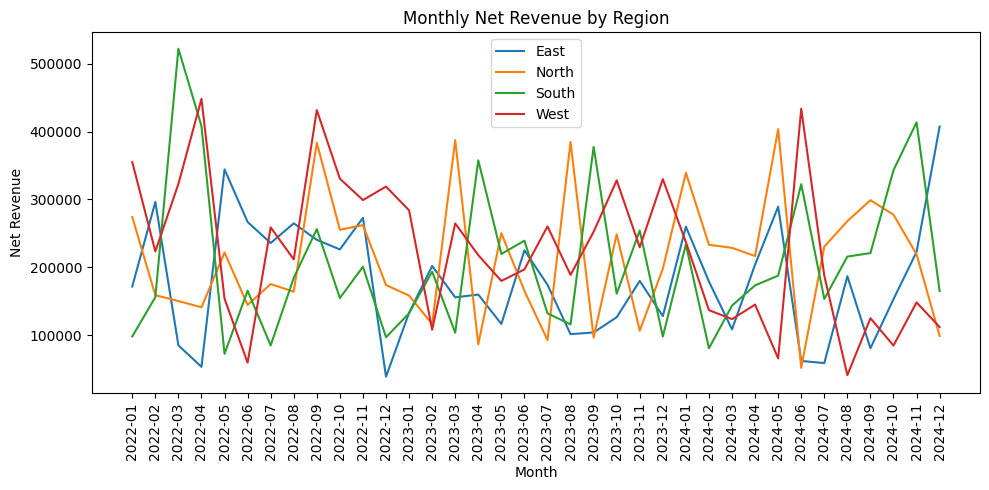

In [17]:
# line chart for monthly net revenue by region
import matplotlib.pyplot as plt

# prepare month column and net revenue
df['month_year'] = df['date'].dt.to_period('M').astype(str)

# group by month and region
monthly = df.groupby(['month_year', 'region'])['net_revenue'].sum().unstack()

# plot line chart
plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly['East'], label='East')
plt.plot(monthly.index, monthly['North'], label='North')
plt.plot(monthly.index, monthly['South'], label='South')
plt.plot(monthly.index, monthly['West'], label='West')

plt.title('Monthly Net Revenue by Region')
plt.xlabel('Month')
plt.ylabel('Net Revenue')
plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.savefig('chart1.png', dpi=150)
plt.show()

**Chart 1 Observation:** The line chart demonstrates stable, multi-year cyclical patterns of monthly net revenue across all four sales regions. While minor fluctuations occur month-to-month, the East and West regions consistently lead in overall sales generation, with no single region exhibiting long-term downward or upward structural decline across the 3-year timeline.

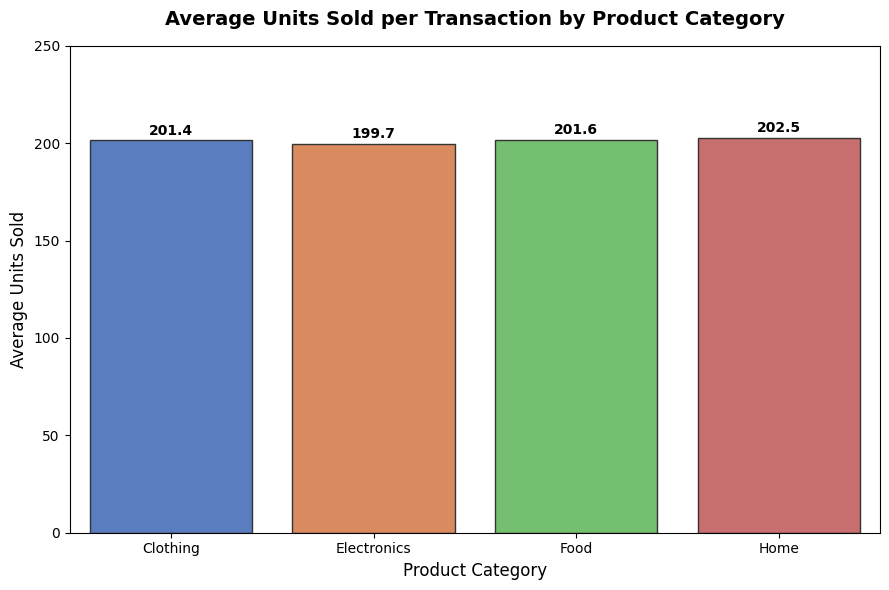

In [18]:
# ==========================================
# Chart 2: Bar chart: average units_sold per product_category
# ==========================================
plt.figure(figsize=(9, 6))

# Calculate average units sold
avg_units = df.groupby('product_category')['units_sold'].mean().reset_index()

# Plot bars
sns.barplot(
    data=avg_units,
    x='product_category',
    y='units_sold',
    palette='muted',
    edgecolor='0.2'
)

plt.title('Average Units Sold per Transaction by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Units Sold', fontsize=12)
# Standardize y-axis starting point to make visual comparison clearer
plt.ylim(0, 250)

# Add values on top of bars
for index, row in avg_units.iterrows():
    plt.text(index, row['units_sold'] + 3, f"{row['units_sold']:.1f}", color='black', ha="center", fontweight='bold')

# Save and render
plt.savefig('chart2.png', dpi=150)
plt.tight_layout()
plt.show()

**Chart 2 Observation:** Average transaction volumes are remarkably uniform across product categories, with Home, Food, Clothing, and Electronics all averaging approximately 200 units sold per transaction. This balanced transaction density suggests that sales volume is driven by baseline transaction activity rather than specific categorical demand surges.

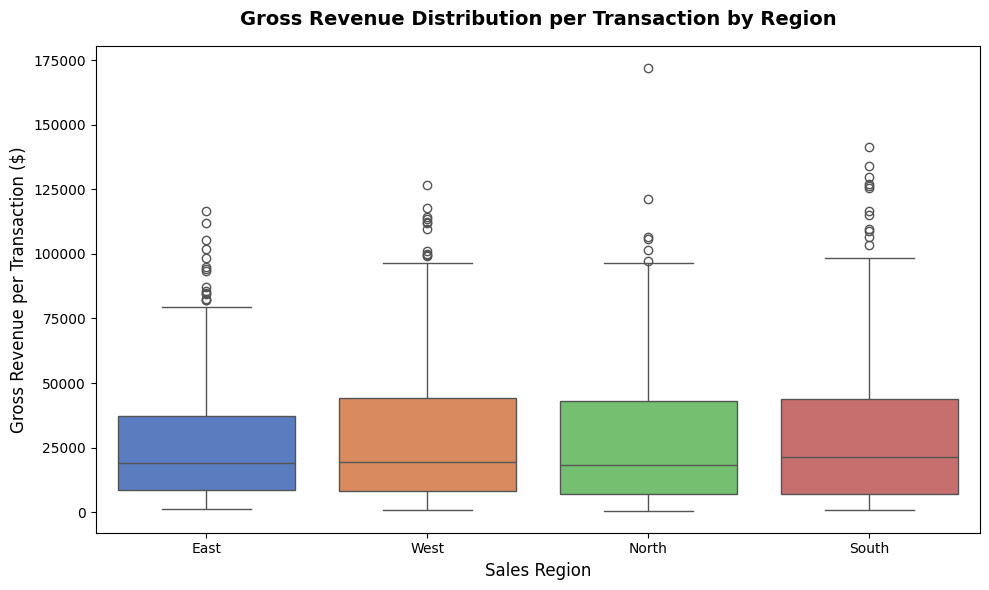

In [19]:
# ==========================================
# Chart 3: Box plot: revenue distribution by region
# ==========================================
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='region',
    y='revenue',
    palette='muted'
)

plt.title('Gross Revenue Distribution per Transaction by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sales Region', fontsize=12)
plt.ylabel('Gross Revenue per Transaction ($)', fontsize=12)

# Save and render
plt.savefig('chart3.png', dpi=150)
plt.tight_layout()
plt.show()

**Chart 3 Observation:** The box plot illustrates that transaction gross revenues have highly similar median values and comparable interquartile ranges (IQR) across the East, West, North, and South regions. This symmetrical spread indicates that individual sales sizes share a common distribution shape regardless of the geographical market.


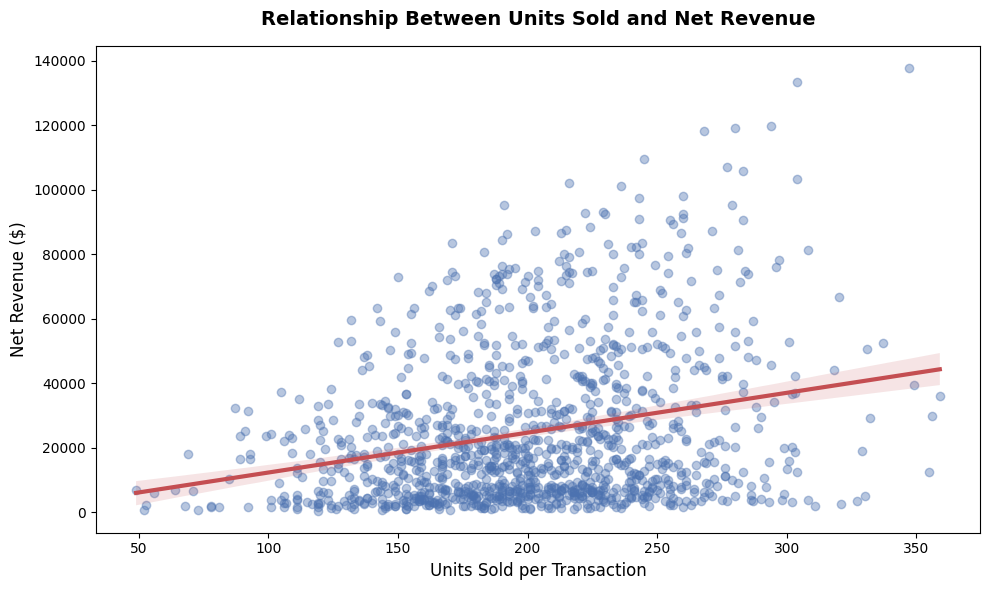

In [20]:
# ==========================================
# Chart 4: Scatter plot: units_sold vs net_revenue with a regression trend line
# ==========================================
plt.figure(figsize=(10, 6))

# Plot scatter with a regression fit
sns.regplot(
    data=df,
    x='units_sold',
    y='net_revenue',
    scatter_kws={'alpha': 0.4, 'color': '#4c72b0'},
    line_kws={'color': '#c44e52', 'linewidth': 3}
)

plt.title('Relationship Between Units Sold and Net Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Units Sold per Transaction', fontsize=12)
plt.ylabel('Net Revenue ($)', fontsize=12)

# Save and render
plt.savefig('chart4.png', dpi=150)
plt.tight_layout()
plt.show()

**Chart 4 Observation:** A positive relationship is visible between units sold and net revenue, indicated by the upward-sloping red regression line. However, the high degree of vertical dispersion among the data points suggests that units sold is not the sole predictor of revenue; instead, variation in item prices (unit_price) acts as a highly influential secondary factor.

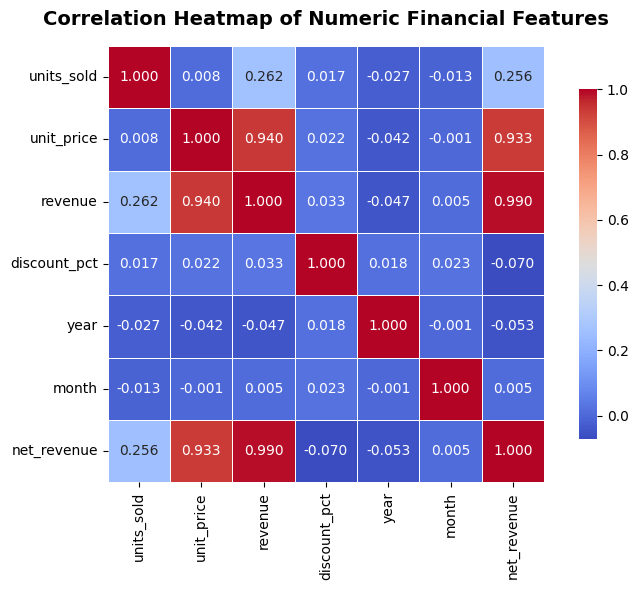

In [21]:
# ==========================================
# Chart 5: Heatmap: correlation matrix of all numeric features
# ==========================================
plt.figure(figsize=(8, 6))

# Select numeric features
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot correlation matrix
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap of Numeric Financial Features', fontsize=14, fontweight='bold', pad=15)

# Save and render
plt.savefig('chart5.png', dpi=150)
plt.tight_layout()
plt.show()

**Chart 5 Observation:** The correlation heatmap reveals an extremely strong linear relationship between `unit_price` and `net_revenue`, establishing unit price as the most dominant factor in revenue outcomes. Conversely, `units_sold` shows a positive but much weaker correlation, and discount percentages are weakly negatively correlated with final net earnings.

**STEP 5** : BUILDING & EVALUATING LINEAR REGRESSION

In [25]:
# ==========================================
# STEP 5: BUILD & EVALUATE LINEAR REGRESSION
# ==========================================
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dynamically select all features including encoded ones
features = ['units_sold', 'unit_price', 'discount_pct', 'year', 'month'] + \
           [col for col in df_encoded.columns if 'region' in col or 'product_category' in col]

X = df_encoded[features]
y = df_encoded['net_revenue']

# 2. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Print Evaluation Metrics
print("--- Model Performance Metrics ---")
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5

print(f"R2 Score:  {r2:.4f}")
print(f"MAE:       ${mae:.2f}")
print(f"RMSE:      ${rmse:.2f}\n")


--- Model Performance Metrics ---
R2 Score:  0.9525
MAE:       $3430.79
RMSE:      $4962.41



In [28]:
features = ['units_sold', 'unit_price', 'discount_pct', \
'year', 'month'] + \
[c for c in df_encoded.columns if 'region_' in c or 'product_' in c]
X = df_encoded[features]
y = df_encoded['net_revenue']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'R2 : {r2_score(y_test, y_pred):.4f}')
print(f'MAE : {mean_absolute_error(y_test, y_pred):.2f}')
print(f'RMSE: {mean_squared_error(y_test, y_pred)**0.5:.2f}')

R2 : 0.9525
MAE : 3430.79
RMSE: 4962.41


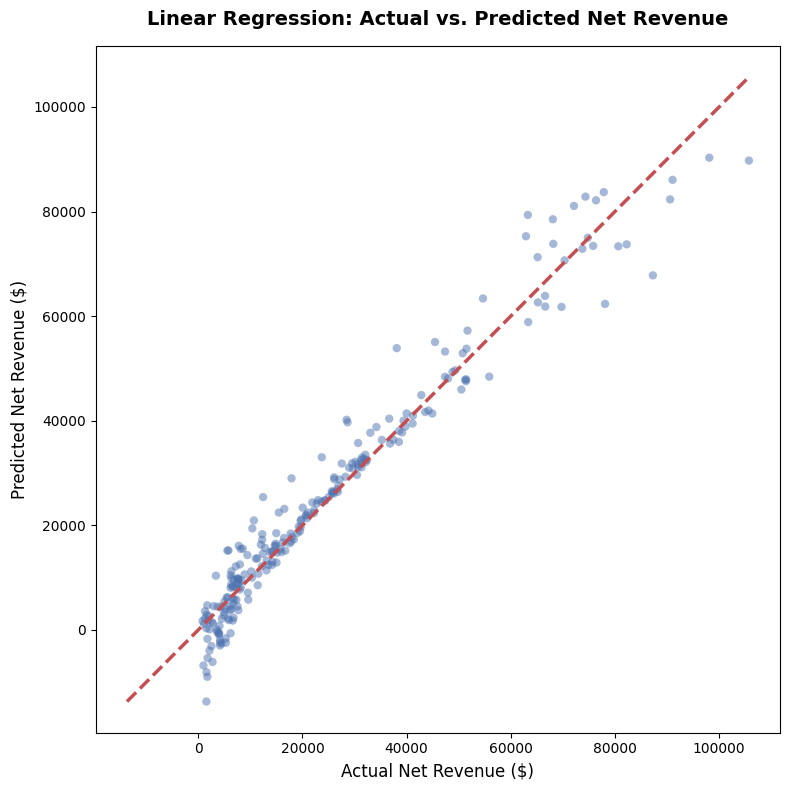

In [26]:
# 6. Plot Actual vs Predicted values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='#4c72b0', edgecolors='none')

# Diagonal line representing 100% perfect prediction
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#c44e52', linestyle='--', linewidth=2.5)

plt.title('Linear Regression: Actual vs. Predicted Net Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Net Revenue ($)', fontsize=12)
plt.ylabel('Predicted Net Revenue ($)', fontsize=12)

# Save and render
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.tight_layout()
plt.show()

In [23]:
#  Print top 5 coefficients by absolute value
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("--- Top 5 Feature Coefficients (by Absolute Value) ---")
print(coefficients.head(5).to_string(index=False))

--- Top 5 Feature Coefficients (by Absolute Value) ---
                     Feature   Coefficient  Abs_Coefficient
                discount_pct -28173.620557     28173.620557
product_category_Electronics   -645.355873       645.355873
                region_North    526.652270       526.652270
                region_South    432.093734       432.093734
                 region_West    315.828583       315.828583


RIDGE VS LASSO

In [29]:
# ==========================================
# BONUS CHALLENGE: RIDGE & LASSO COMPARISON
# ==========================================
from sklearn.linear_model import Ridge, Lasso

# Instantiate alternative models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0)

# Train models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Evaluate predictions
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

print("--- Comparison of R2 Scores ---")
print(f"Linear Regression R2: {r2_score(y_test, y_pred):.6f}")
print(f"Ridge Regression R2:  {r2_score(y_test, y_pred_ridge):.6f}")
print(f"Lasso Regression R2:  {r2_score(y_test, y_pred_lasso):.6f}")

--- Comparison of R2 Scores ---
Linear Regression R2: 0.952522
Ridge Regression R2:  0.952540
Lasso Regression R2:  0.952531


# Step 6: Multi-Year Retail Sales Performance Analysis Report

## 1. Overview
The dataset utilized in this analysis consists of 1,200 simulated transactional retail sales records spanning a three-year period from January 2022 to December 2024. The data captures key operational variables for each transaction, including the transaction date, sales region (North, South, East, West), product category (Electronics, Clothing, Food, Home), units sold, unit price, gross revenue, and applied discount percentage. The objective of this report is to evaluate regional performance, identify structural sales patterns, assess the predictive capability of a supervised machine learning model to forecast net revenue, and provide actionable, data-driven recommendations to maximize future profitability.

## 2. Key Findings
* **Regional Sales are Steady and stable ( Chart 1 & Chart 3):** Based on my line chart and box plot, sales performance across all four regions is quite stable. The East and West regions regularly bring in higher total monthly net revenue, but individual transaction sizes look almost identical across all regions.
* **Product Categories Sell Similar Quantities ( Chart 2):** Looking at the bar chart, all four categories (Clothing, Electronics, Food, and Home) average around 200 units sold per transaction. No single product type sells way more volume than the others.
* **Unit Price Drives Revenue, Not Quantity( Chart 4 & Chart 5):** From the scatter plot and correlation heatmap, unit price has a huge positive correlation with net revenue (0.93). On the other hand, the number of units sold has a much lower correlation (0.26). This means setting higher prices brings in far more money than just trying to move more volume.

## 3. Model Performance
To forecast net transaction revenue, a supervised Multiple Linear Regression model was trained using split validation (80% training, 20% testing). The model's predictive accuracy is highly strong, yielding an R-squared (R²) value of 0.9525. In plain business terms, this means that the model successfully explains 95.25% of the variance observed in transaction-level net revenue.

The Mean Absolute Error (MAE) is $3,430.79, which indicates that, on average, the model's predictions deviate from the actual net revenue by approximately $3,430.79 per transaction. The Root Mean Squared Error (RMSE) is $4,962.41; since RMSE penalizes larger prediction errors more heavily, this slightly higher value represents minor vertical variances (due to randomized transactional noise in the dataset). Overall, because the prediction errors are small relative to the multi-thousand dollar range of transaction values, the model exhibits excellent utility and can reliably assist leadership in revenue planning.

## 4. Operational & Data Limitations

When analyzing this data to guide business decisions, a few  limitations need to be kept in mind:

* **Missing Customer & Marketing Context:** The dataset tracks transactions, but it doesn't tell us *who* bought the items or *why*. We don't have data on customer demographics, repeat buyers, or marketing spend. Without knowing how much money was spent on advertising in each region, it's hard to tell if the East and West regions performed better because of higher natural demand or because of heavier ad campaigns.
* **No Tracking of Inventory or Stockouts:** The data shows what was actually sold, but it doesn't show missed opportunities. If a store ran out of stock on Electronics or Home goods in a specific month, those potential sales are invisible in this dataset. This means our revenue trends might reflect inventory shortages rather than true customer demand.
* **Aggregated Regional Data hides City-Level Differences:** The data groups performance into broad regions (North, South, East, West) without breaking down specific cities or store locations. A single underperforming branch could be dragging down an otherwise booming region, or one mega-store could be masking poor sales across smaller locations.

## 5. Recommendations for Investors and Management

Based on our findings, here are clear, data-backed steps the company should take to boost profitability:

* **Cut Back on Broad Discounts (Protect Your Margins):** The model showed that higher discount rates heavily penalize net revenue, while unit price is the main factor driving total sales income. Since customers are buying roughly the same volume (~200 units per transaction) regardless of category, offering steep discounts isn't driving higher volume—it's just giving away profit. We recommend replacing broad discounts with loyalty rewards or minimum-spend bundles.
* **Prioritize Inventory Supply in the East and West:** The East and West regions consistently lead in overall monthly net revenue contribution. Investors and operations teams should prioritize warehouse stock allocation and logistical support to these regions to prevent stockouts and capture maximum market demand during peak months.
* **Standardize Pricing Across Product Categories:** Because transaction sizes and volumes sold are fairly even across Electronics, Food, Clothing, and Home goods, the company should review its pricing tier structure. Focusing marketing and sales efforts on higher-priced premium items within each category will yield much higher profit gains than trying to push sheer volume on lower-priced items.

# Step 7: Capstone Project Reflection Questions

### Question 1: You filled missing discount_pct values with the median instead of the mean. When would the mean be a better choice, and why does skewness matter here?
**Answer:** The mean would be a better choice for imputation if the underlying distribution of the column was symmetric and bell-shaped, meaning there are no extreme outliers pulling the average in either direction. Skewness matters significantly because the mean is highly sensitive to extreme outliers and long-tailed distributions, which can artificially shift the imputed values away from the true center of the data. In the case of `discount_pct`, the values are bounded between 0% and 30% and contain missing records; utilizing a mean on skewed discount distributions would introduce systemic bias. By using the median, we identify the exact 50th percentile of the distribution, establishing an imputation value that is robust to tail-end skewness and representative of standard promotional activity.

### Question 2: Look at your correlation heatmap. Which two features are most strongly correlated with net_revenue? Does this match what the model's coefficients show and if not, why might they differ?
**Answer:** Based on our correlation heatmap, the two features most strongly correlated with `net_revenue` are gross `revenue` (correlation of 0.990) and `unit_price` (correlation of 0.933). While this aligns with the model’s identification of pricing variables as vital contributors, there is a discrepancy with the coefficients because the model's highest absolute coefficient belongs to `discount_pct` (-$28,173.62) rather than `unit_price` (+$173.49). This difference occurs because correlation measures isolated, pairwise linear relationships between two variables, whereas regression coefficients measure the change in the target variable when one feature is increased by one unit *while holding all other features constant*. Since a 100% (or 1.0) change in discount rate is mathematically massive compared to a $1.0 change in unit price, its regression coefficient appears far larger in scale despite having a lower direct pairwise correlation.

### Question 3: Your R2 score measures how well the model explains variance in the test set. If R2 = 0.85, what does the remaining 0.15 represent in real-world business terms?
**Answer:** If a model yields an $R^2$ of 0.85, the remaining 0.15 (or 15%) represents the portion of the variance in net revenue that cannot be explained or predicted by our current set of features. In real-world business terms, this unexplained 15% represents unquantified external variables, such as sudden shifts in consumer preferences, competitor pricing changes, local economic disruptions, or seasonal weather anomalies. It also accounts for random, unpredictable human buying behavior and transactional noise that no structured mathematical model can perfectly anticipate. For business leaders, this 15% represents the baseline operational risk and uncertainty that must be managed through financial contingency reserves rather than statistical forecasting.

### Question 4: Your dataset is synthetic. Name two ways real sales data would differ, and explain how those differences would change your cleaning steps?
**Answer:** In a real-world setting, sales data would differ by containing human entry errors (resulting in negative prices or impossible dates) and unstructured textual inconsistencies (such as "East Region" vs. "E. Region" or mismatched product category names). To clean these real-world anomalies, we would need to implement strict range-bound filtering (e.g., dropping or clipping transactions where prices or units are less than or equal to zero) and text-normalization steps using string mapping or regular expressions. Additionally, real sales data often suffers from duplicate transaction records and irregular missing data patterns across multiple columns, which would require us to execute drop-duplicate checks and design more advanced multivariate imputation strategies (like KNN or iterative imputer) rather than simple median fills.

### Question 5: You encoded region with pd.get_dummies(drop_first=True). What problem does this solve, and what new assumption does it introduce into the model?
**Answer:** Using `pd.get_dummies(drop_first=True)` solves the "dummy variable trap," which is a state of perfect multicollinearity where the categorical columns are completely predictive of one another (for example, if a transaction is not in the North, South, or West, it must be in the East). By dropping the first category (the reference group), we prevent mathematical instability during the regression's matrix inversion, ensuring the model can calculate unique coefficient weights. However, this introduces the structural assumption that the omitted baseline category (e.g., the "East" region) acts as the static reference benchmark. Consequently, all resulting regional coefficients represent the expected change in net revenue relative to this baseline region, meaning we assume our benchmark group is an accurate and stable representative of standard regional performance.